# Goal: Fairness Metrics Computation
The goal of this notebook is given:
- a dataset D
- a target variable
- a sensible attribute
- a legittimate attribute (needed only for one specific metric)

it computes the statistical fairness metrics presented in Verma and Rubin paper https://dl.acm.org/doi/pdf/10.1145/3194770.3194776 + Aequitas metrics https://arxiv.org/pdf/1811.05577.pdf.

The running example is the Credit Score dataset https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk



## Only for Colab environment

In [1]:
#online for colab environment
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Import e Preprocessing

In [2]:
%cd /content/drive/MyDrive/USA/preprocessing/

/content/drive/MyDrive/USA/preprocessing


In [3]:
from distribution_utils import *

In [4]:
%cd /content/drive/MyDrive/USA/AdultCensus

/content/drive/MyDrive/USA/AdultCensus


## Load the dataset

In [5]:
dataset_path = 'adult.csv'
#dataset_path = 'german.csv'
df=pd.read_csv(dataset_path)
df.head(15)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [6]:
print(df.race.unique())

['White' 'Black' 'Asian-Pac-Islander' 'Other' 'Amer-Indian-Eskimo']


In [7]:
print(df['native.country'].unique())

['United-States' '?' 'Mexico' 'Greece' 'Vietnam' 'China' 'Taiwan' 'India'
 'Philippines' 'Trinadad&Tobago' 'Canada' 'South' 'Holand-Netherlands'
 'Puerto-Rico' 'Poland' 'Iran' 'England' 'Germany' 'Italy' 'Japan' 'Hong'
 'Honduras' 'Cuba' 'Ireland' 'Cambodia' 'Peru' 'Nicaragua'
 'Dominican-Republic' 'Haiti' 'El-Salvador' 'Hungary' 'Columbia'
 'Guatemala' 'Jamaica' 'Ecuador' 'France' 'Yugoslavia' 'Scotland'
 'Portugal' 'Laos' 'Thailand' 'Outlying-US(Guam-USVI-etc)']


## Preprocessing

In [8]:
df[df.columns].isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [9]:
for c in df.columns:
   print(c, (df[c] == '?').sum())

age 0
workclass 1836
fnlwgt 0
education 0
education.num 0
marital.status 0
occupation 1843
relationship 0
race 0
sex 0
capital.gain 0
capital.loss 0
hours.per.week 0
native.country 583
income 0


In [10]:
df = df.drop(columns=['native.country', 'fnlwgt', 'occupation', 'workclass', 'education'])
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,Widowed,Not-in-family,White,Female,0,4356,40,<=50K
1,82,9,Widowed,Not-in-family,White,Female,0,4356,18,<=50K
2,66,10,Widowed,Unmarried,Black,Female,0,4356,40,<=50K
3,54,4,Divorced,Unmarried,White,Female,0,3900,40,<=50K
4,41,10,Separated,Own-child,White,Female,0,3900,40,<=50K


In [11]:
print(len(df))
df = df.dropna()
df.head()
print(len(df))

32561
32561


In [12]:
df['race'] = df['race'].replace({'White': 1, 'Asian-Pac-Islander': 1, 'Black':0, 'Other':0, 'Amer-Indian-Eskimo':0})

<ipython-input-12-f8cf0bf15a8c>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['race'] = df['race'].replace({'White': 1, 'Asian-Pac-Islander': 1, 'Black':0, 'Other':0, 'Amer-Indian-Eskimo':0})


In [13]:
# Initialize encoder
encoder = LabelEncoder()

# # Fit and transform column
# df['race'] = encoder.fit_transform(df['race'])
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,Widowed,Not-in-family,1,Female,0,4356,40,<=50K
1,82,9,Widowed,Not-in-family,1,Female,0,4356,18,<=50K
2,66,10,Widowed,Unmarried,0,Female,0,4356,40,<=50K
3,54,4,Divorced,Unmarried,1,Female,0,3900,40,<=50K
4,41,10,Separated,Own-child,1,Female,0,3900,40,<=50K


In [14]:
# mapping = {category: code for code, category in enumerate(encoder.classes_)}
# print(mapping)

In [15]:
df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})

<ipython-input-15-426cec34a599>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'Female': 0, 'Male': 1})


In [16]:
df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})
df.head()

<ipython-input-16-7de08b99d98a>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace({'<=50K': 0, '>50K': 1})


,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,Widowed,Not-in-family,1,0,0,4356,40,0
1,82,9,Widowed,Not-in-family,1,0,0,4356,18,0
2,66,10,Widowed,Unmarried,0,0,0,4356,40,0
3,54,4,Divorced,Unmarried,1,0,0,3900,40,0
4,41,10,Separated,Own-child,1,0,0,3900,40,0


In [17]:
df['marital.status'] = encoder.fit_transform(df['marital.status'])
mapping = {category: code for code, category in enumerate(encoder.classes_)}
print(mapping)
df['relationship'] = encoder.fit_transform(df['relationship'])
mapping = {category: code for code, category in enumerate(encoder.classes_)}
print(mapping)
df.head()

{'Divorced': 0, 'Married-AF-spouse': 1, 'Married-civ-spouse': 2, 'Married-spouse-absent': 3, 'Never-married': 4, 'Separated': 5, 'Widowed': 6}
{'Husband': 0, 'Not-in-family': 1, 'Other-relative': 2, 'Own-child': 3, 'Unmarried': 4, 'Wife': 5}


,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,90,9,6,1,1,0,0,4356,40,0
1,82,9,6,1,1,0,0,4356,18,0
2,66,10,6,4,0,0,0,4356,40,0
3,54,4,0,4,1,0,0,3900,40,0
4,41,10,5,3,1,0,0,3900,40,0


In [18]:
df.loc[df['age'].between(17, 35, 'both'), 'age'] = 0
df.loc[df['age'].between(35, 90, 'right'), 'age'] = 1
df.head()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,9,6,1,1,0,0,4356,40,0
1,1,9,6,1,1,0,0,4356,18,0
2,1,10,6,4,0,0,0,4356,40,0
3,1,4,0,4,1,0,0,3900,40,0
4,1,10,5,3,1,0,0,3900,40,0


In [19]:
df.age.unique()

array([1, 0])

In [20]:
df.describe()

,age,education.num,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,0.541630,10.080679,2.611836,1.446362,0.886183,0.669205,1077.648844,87.303830,40.437456,0.240810
std,0.498272,2.572720,1.506222,1.606771,0.317594,0.470506,7385.292085,402.960219,12.347429,0.427581
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,9.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,0.000000
50%,1.000000,10.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,40.000000,0.000000
75%,1.000000,12.000000,4.000000,3.000000,1.000000,1.000000,0.000000,0.000000,45.000000,0.000000
max,1.000000,16.000000,6.000000,5.000000,1.000000,1.000000,99999.000000,4356.000000,99.000000,1.000000


In [21]:
df.loc[df['education.num'].between(0, 9, 'both'), 'education.num'] = 0
df.loc[df['education.num'].between(9, 16, 'right'), 'education.num'] = 1
df = df.rename(columns={'education.num': 'edu'})
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Save preprocessed dataset

In [22]:
df.to_csv("adult-preprocessed-2race-2age-2edu.csv", sep=',', index=False, encoding='utf-8')

# Distribution Analysis

In [ ]:
protected_attributes =['age', 'sex', 'race', 'edu']
target = 'income'
dataset_path= 'adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

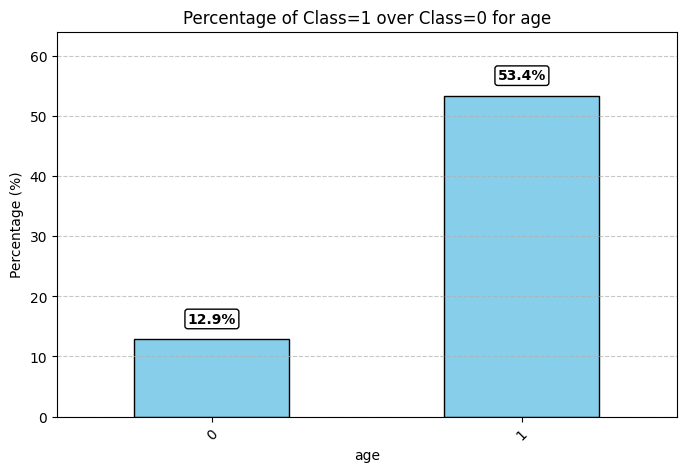

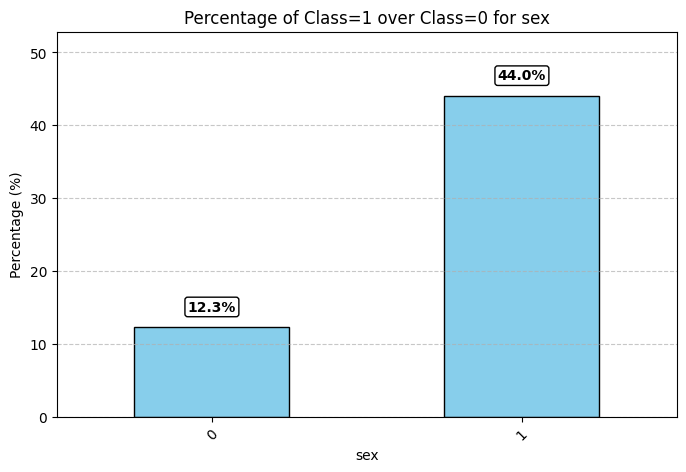

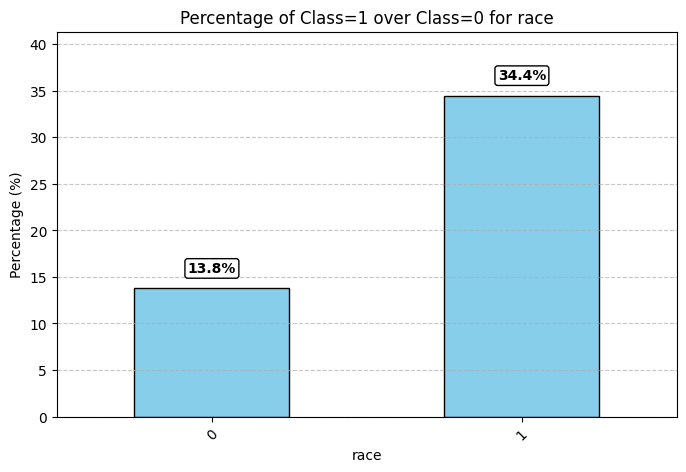

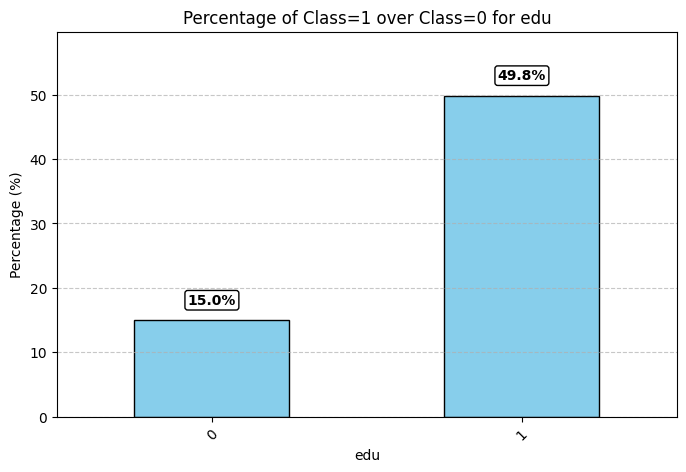

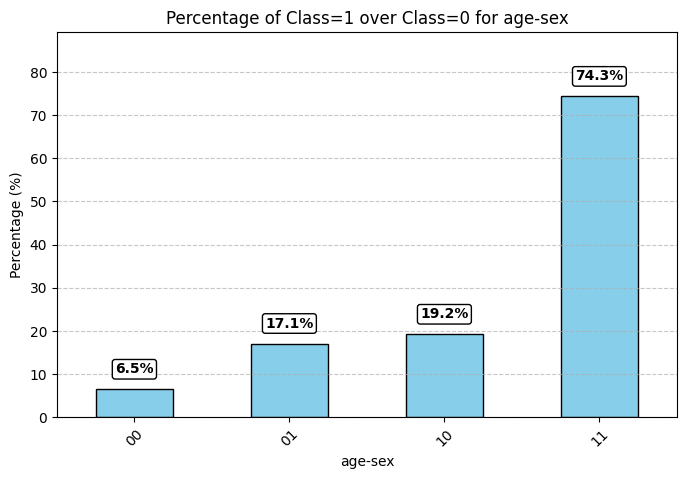

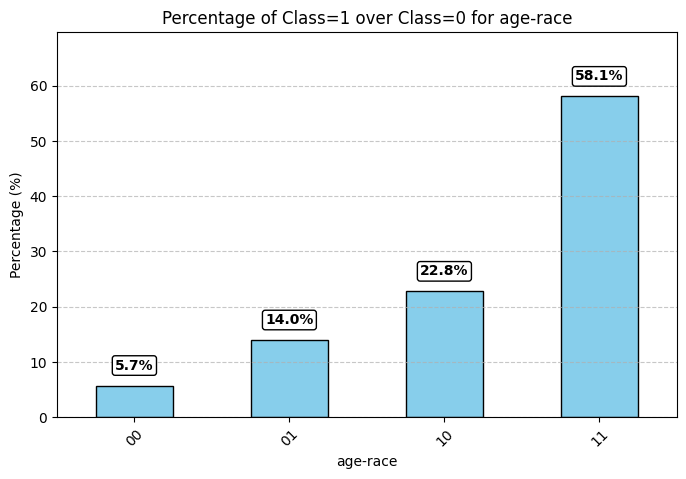

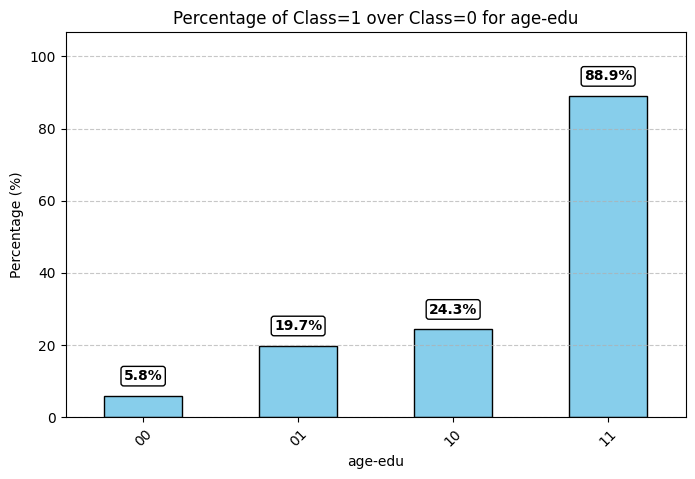

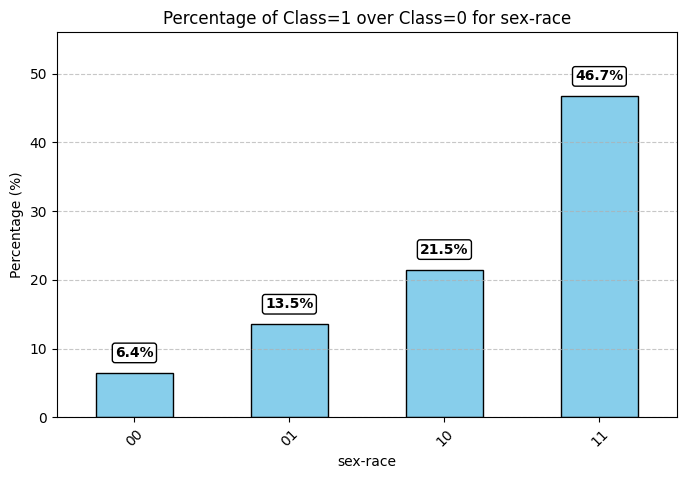

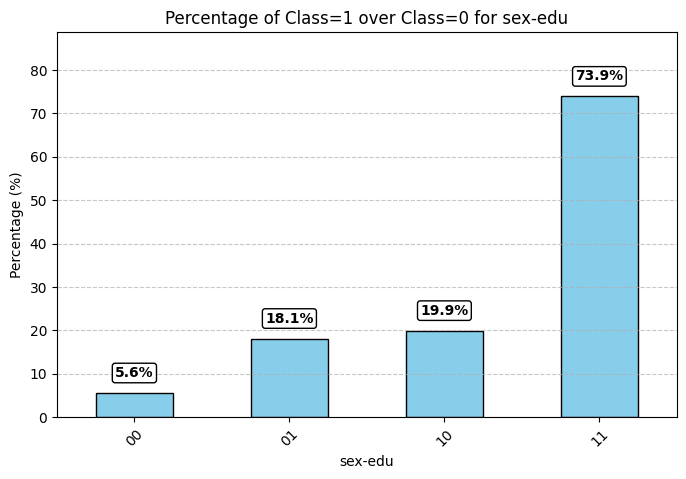

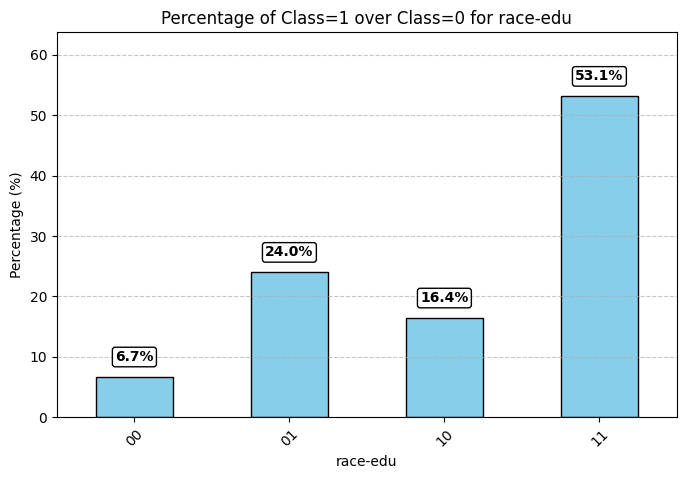

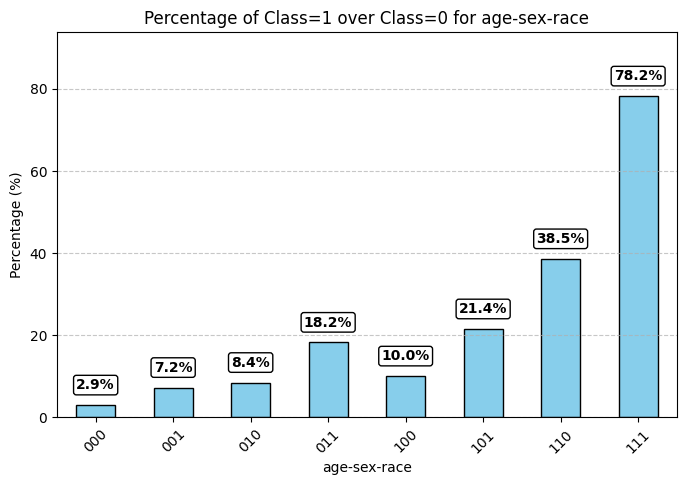

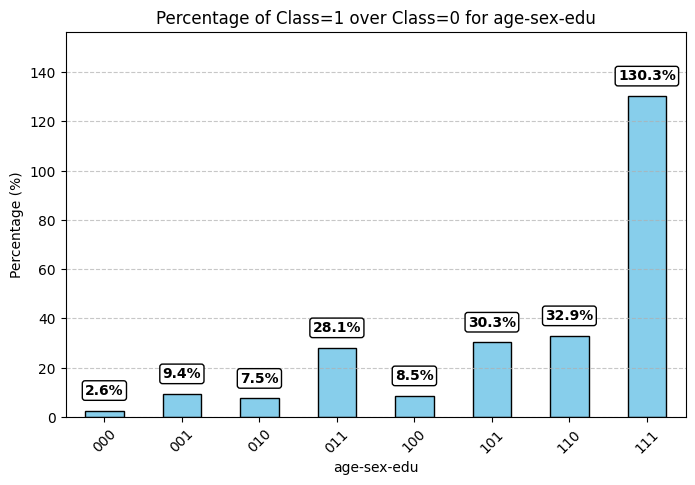

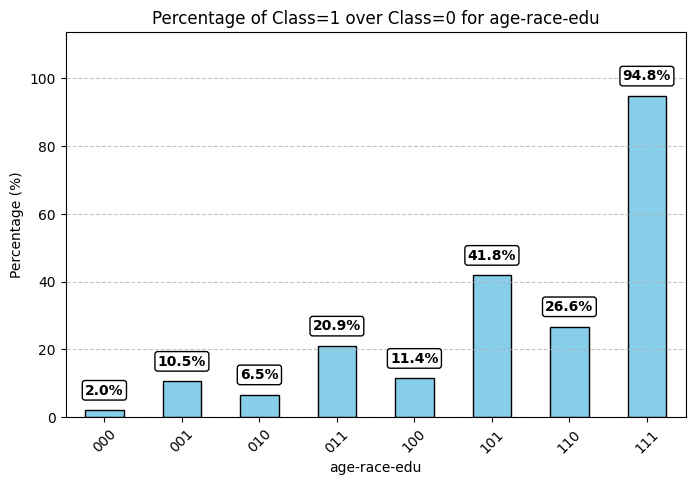

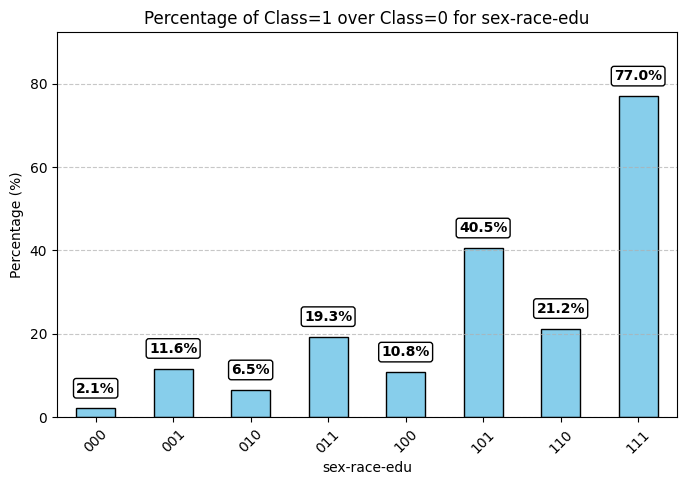

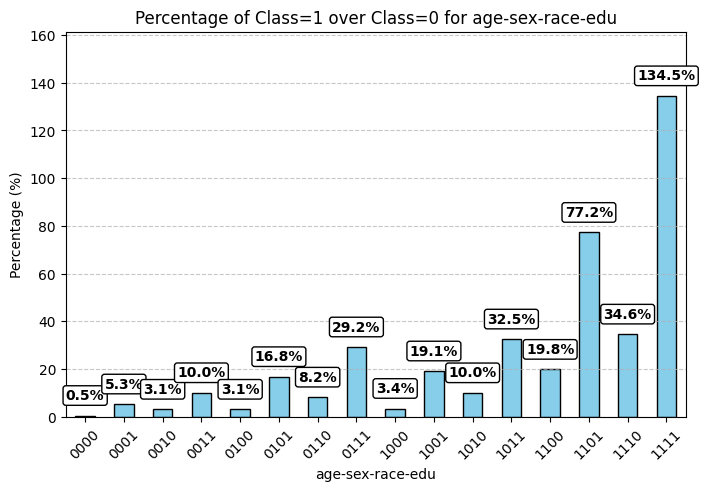

In [ ]:
plot_percentage(dataset_path, target, protected_attributes)

['age']


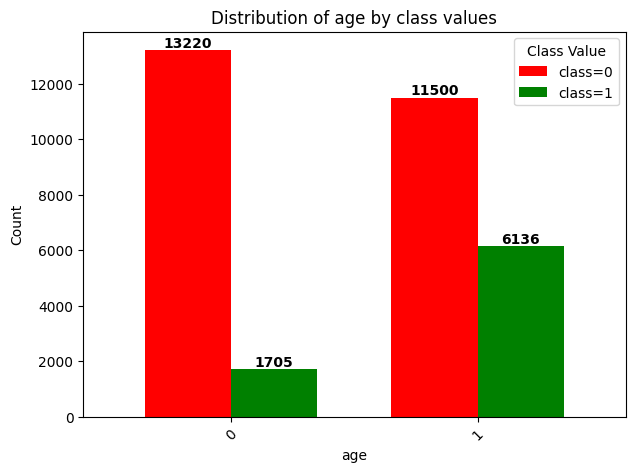

['sex']


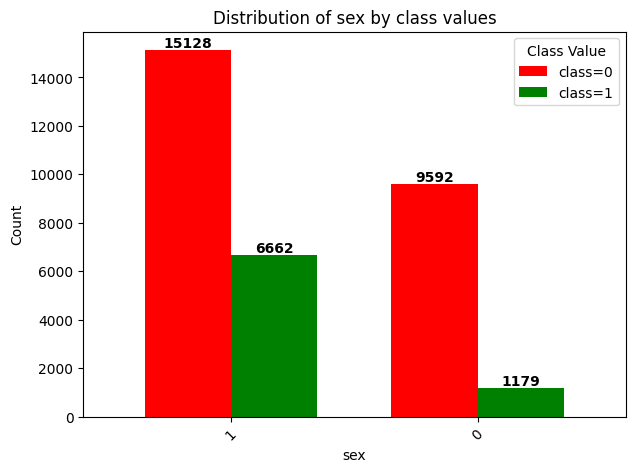

['race']


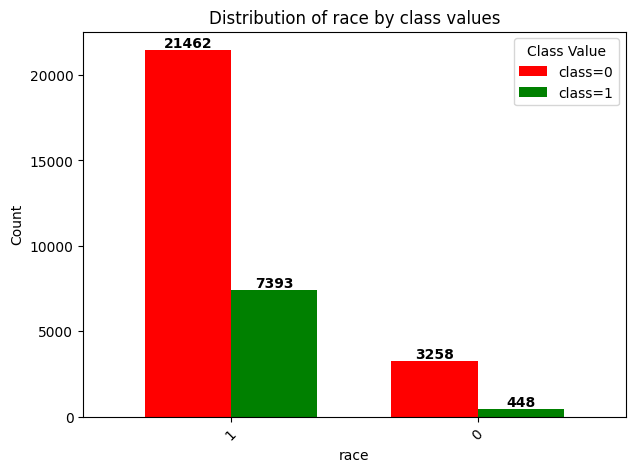

['edu']


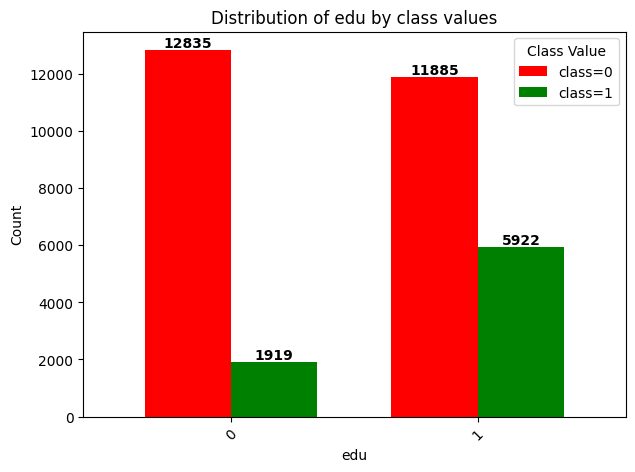

['age', 'sex']


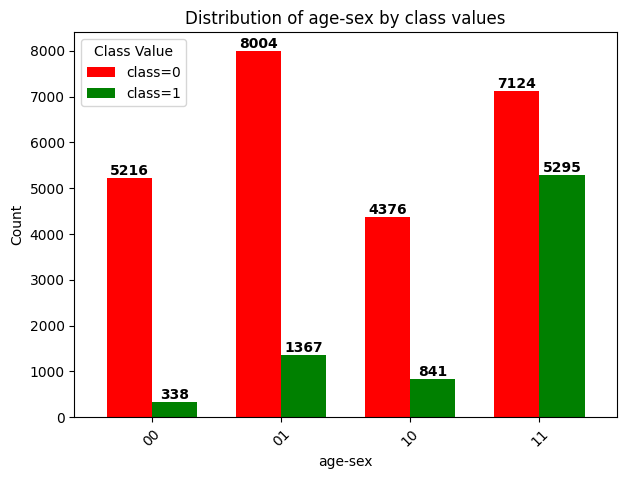

['age', 'race']


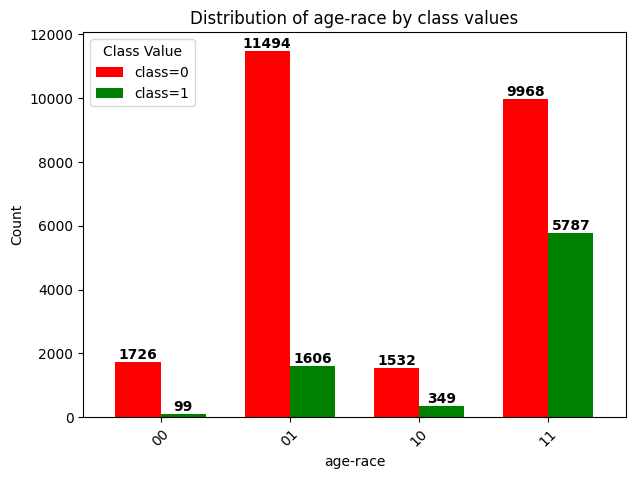

['age', 'edu']


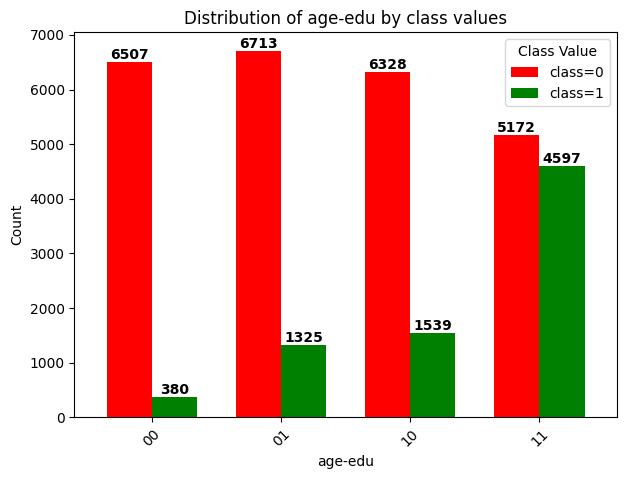

['sex', 'race']


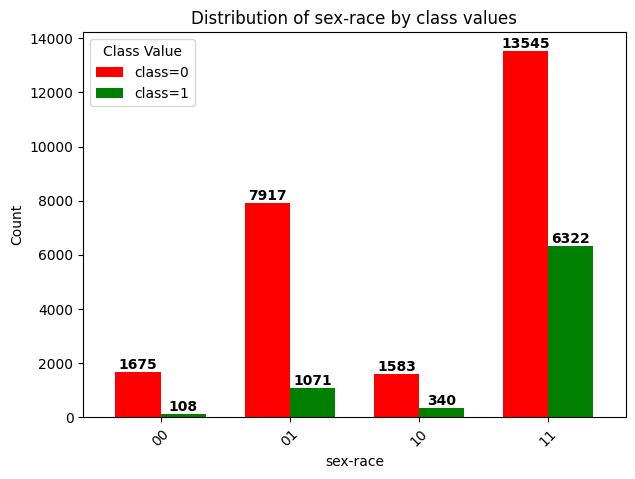

['sex', 'edu']


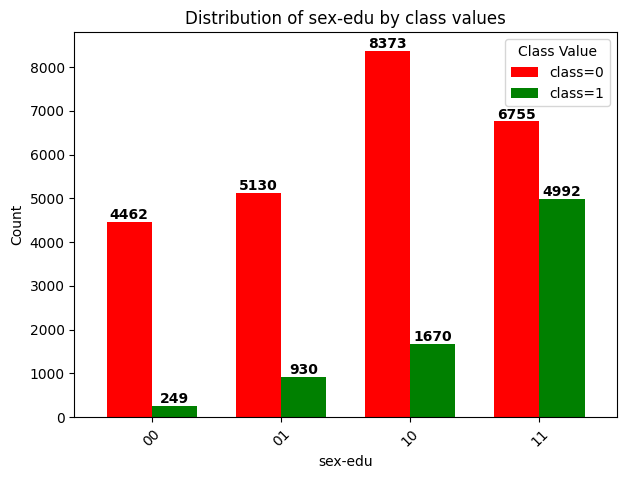

['race', 'edu']


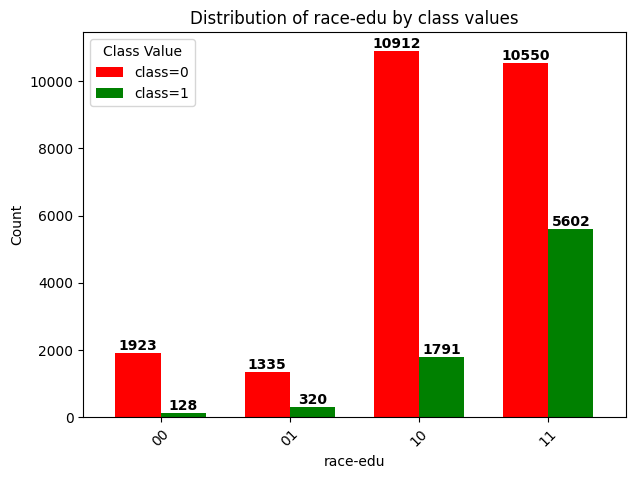

['age', 'sex', 'race']


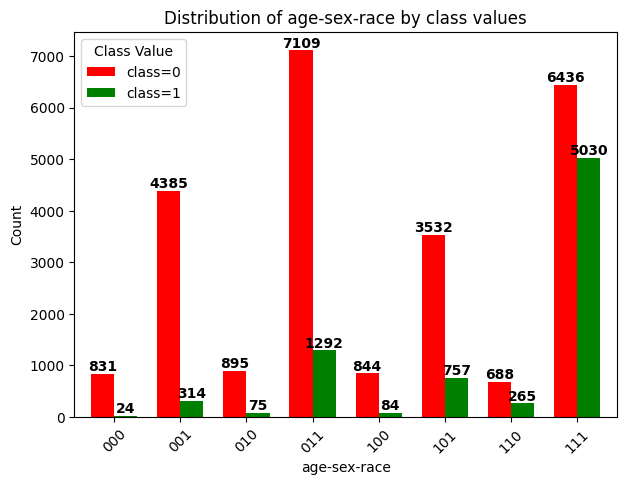

['age', 'sex', 'edu']


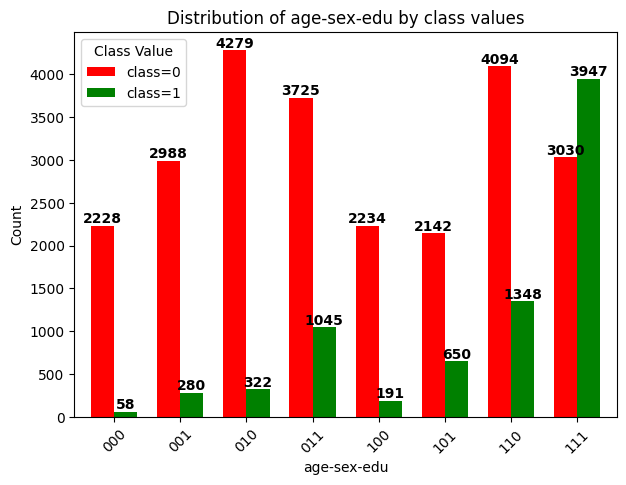

['age', 'race', 'edu']


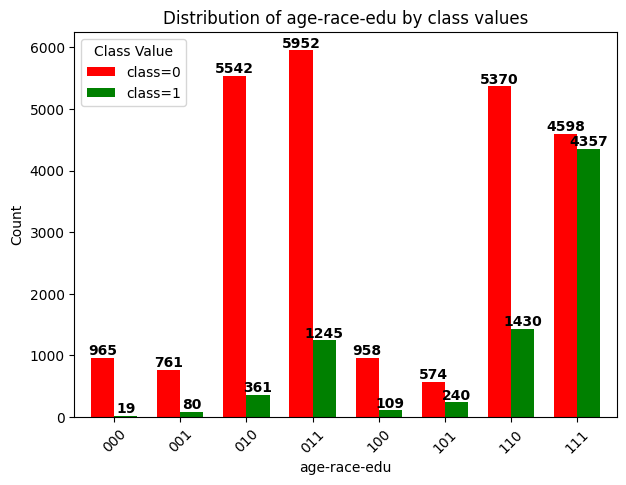

['sex', 'race', 'edu']


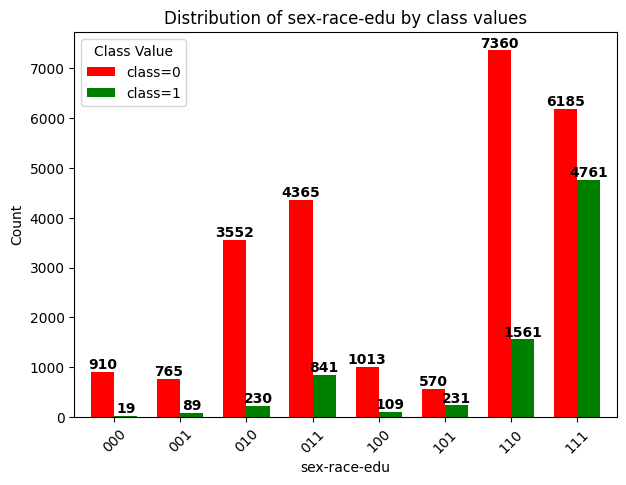

['age', 'sex', 'race', 'edu']


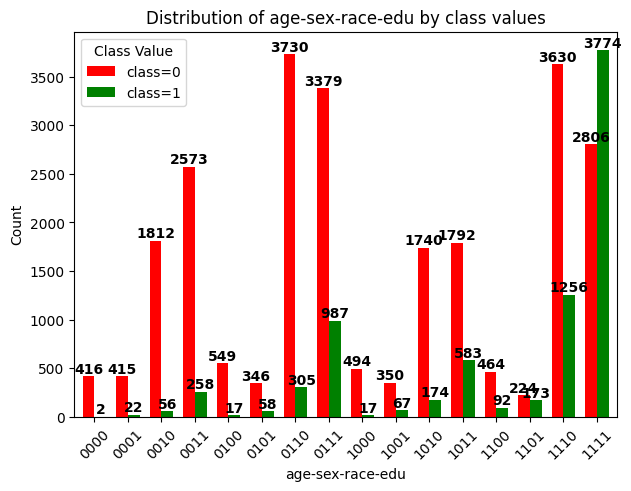

In [ ]:
create_all_plots(dataset_path, protected_attributes, target)

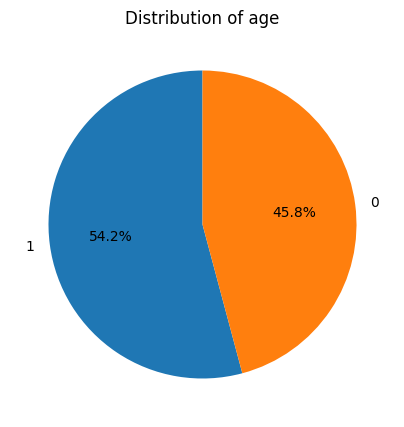

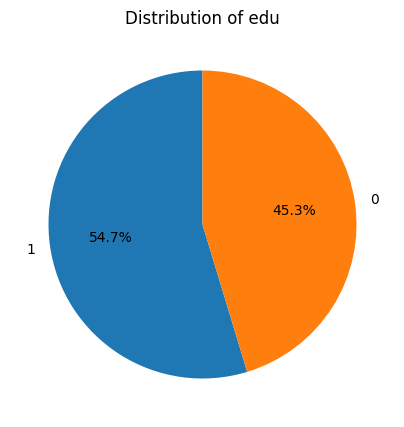

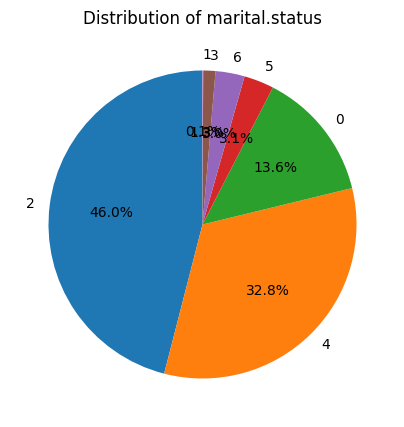

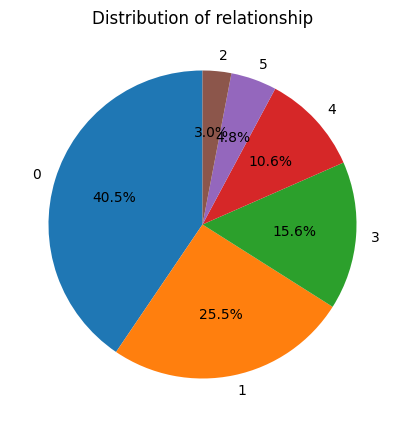

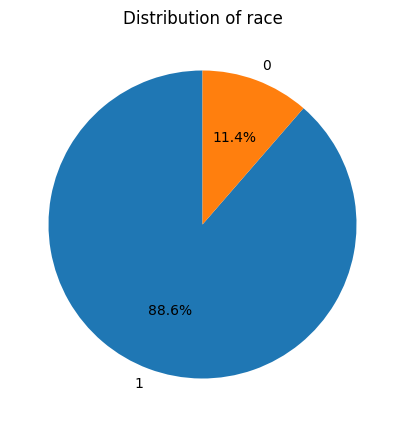

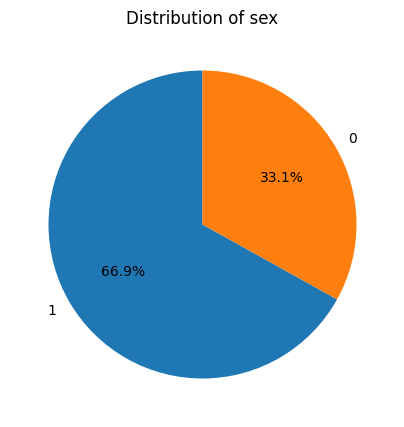

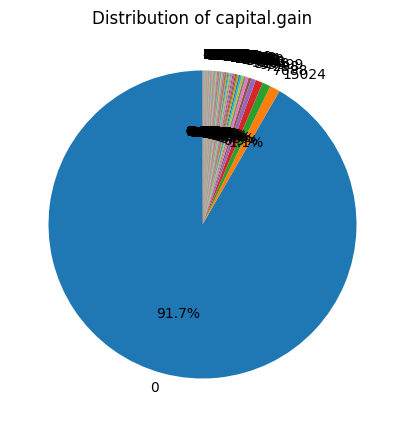

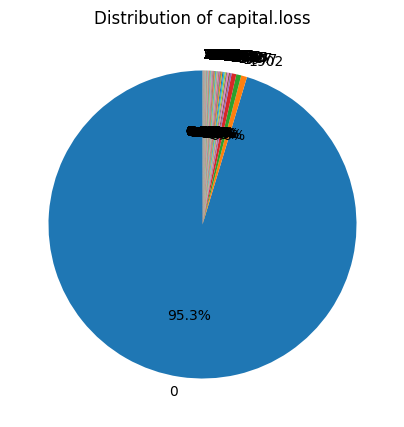

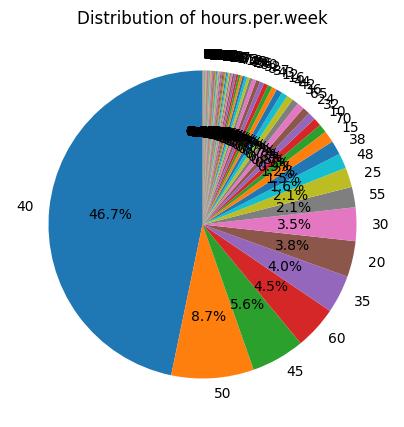

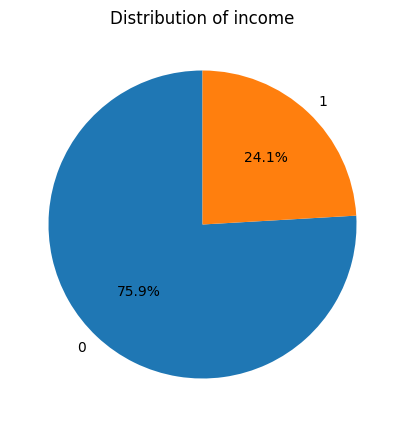

In [ ]:
plot_occurencies(df)

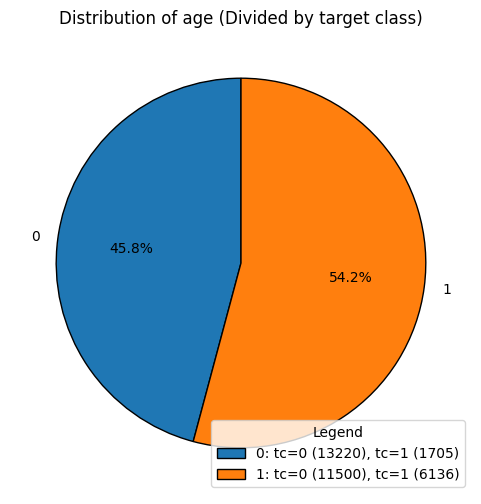

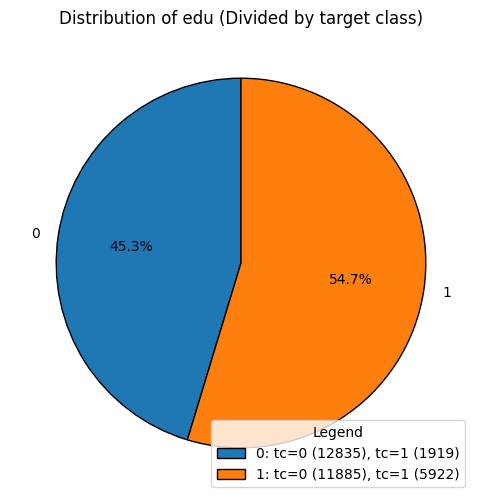

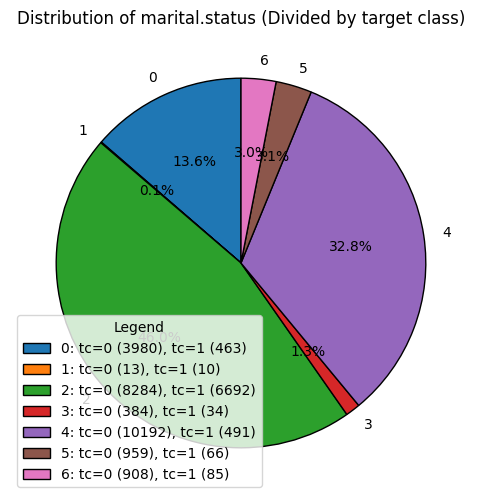

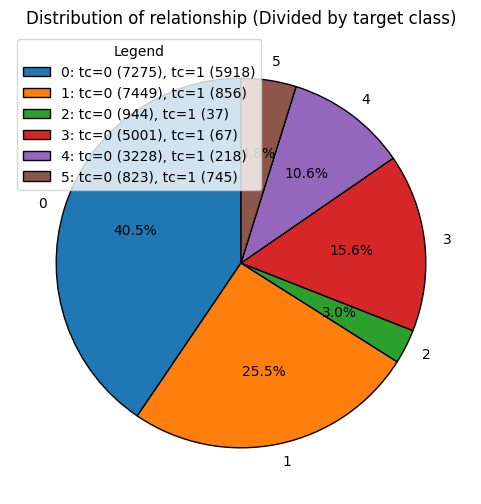

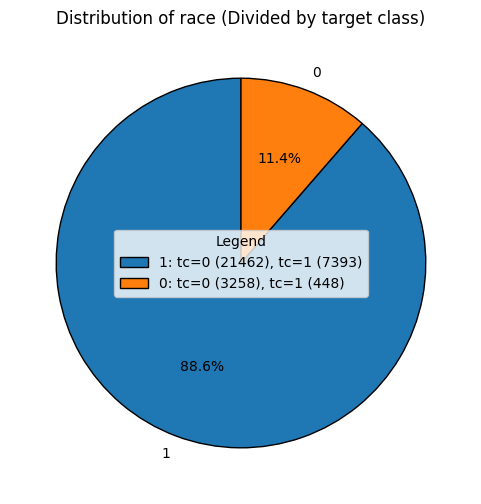

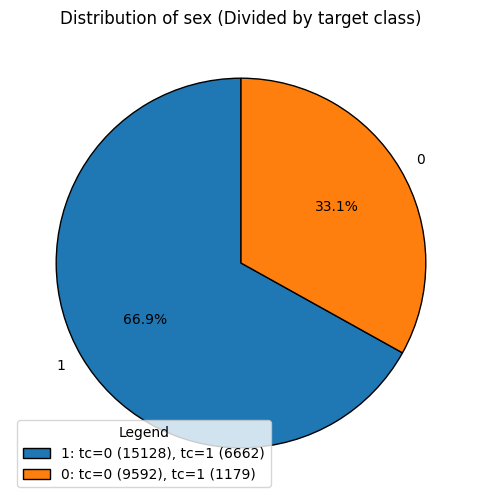

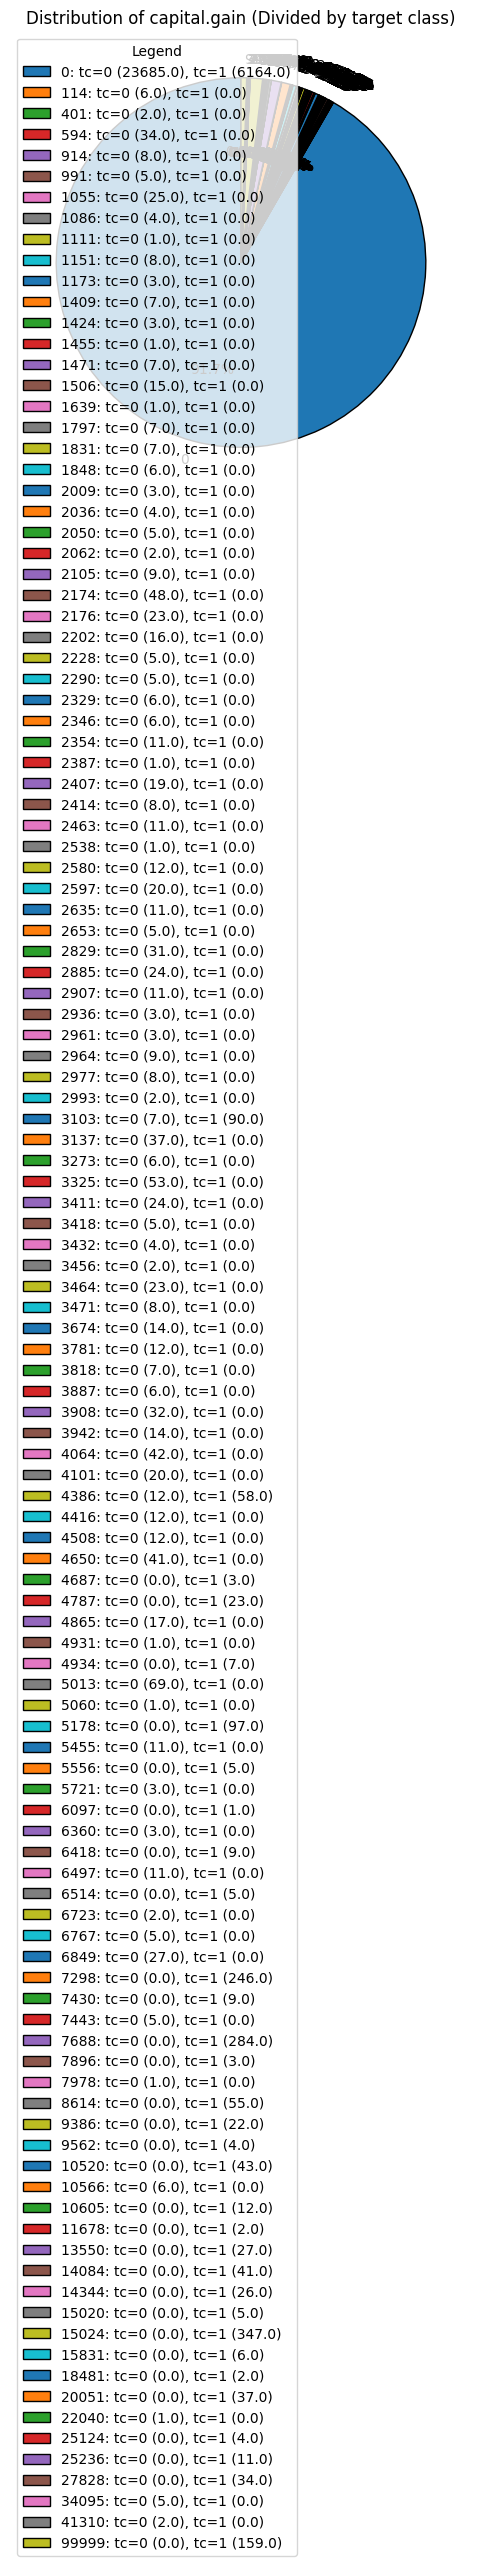

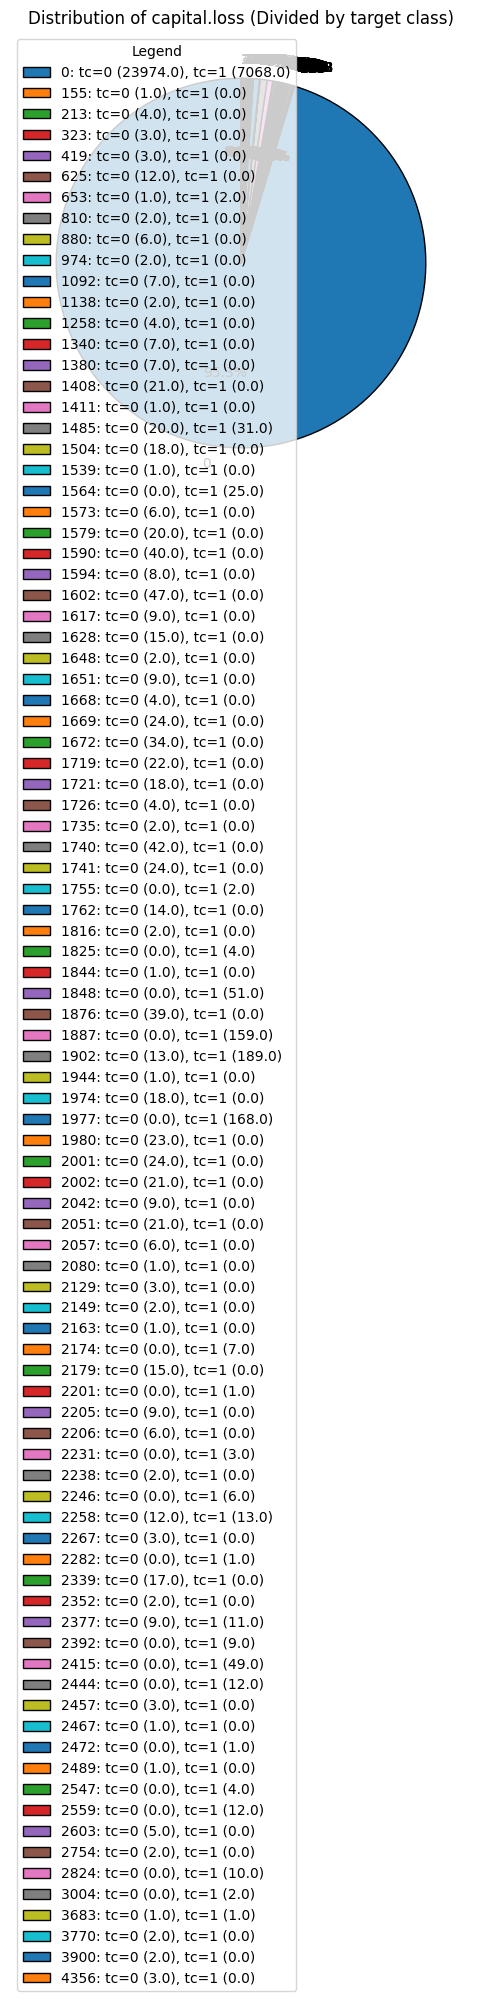

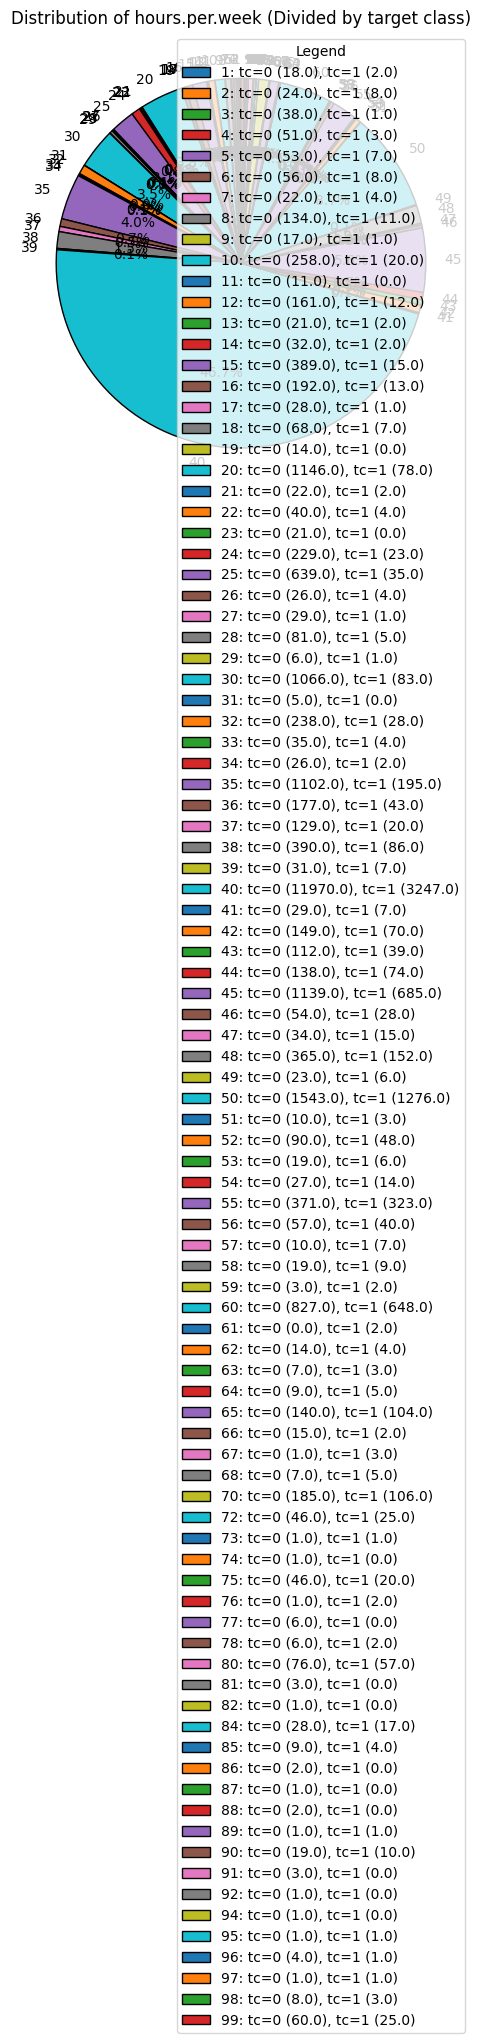

In [ ]:
# Get unique column names except 'C'
target = 'income'
columns_to_plot = [col for col in df.columns if col != target]

# Create pie charts
for col in columns_to_plot:
    counts_C0 = df[df[target] == 0][col].value_counts()
    counts_C1 = df[df[target] == 1][col].value_counts()

    # Ensure both have the same index set (aligning missing values)
    counts_df = pd.DataFrame({'tc=0': counts_C0, 'tc=1': counts_C1}).fillna(0)

    # Plot stacked pie chart
    plt.figure(figsize=(6, 6))
    plt.pie(
        counts_df.sum(axis=1), labels=counts_df.index,
        autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'}
    )

    # Add legend for C=0 and C=1
    plt.legend(
        labels=[f"{index}: tc=0 ({row['tc=0']}), tc=1 ({row['tc=1']})"
                for index, row in counts_df.iterrows()],
        title="Legend"
    )

    plt.title(f"Distribution of {col} (Divided by target class)")
    plt.show()